# [OR-2 Term Project] 미디어관 엘리베이터 대기 시스템 분석
## 현장 실측 서비스 타임 전처리 및 분포 피팅 — 도착률 λ · 서비스율 μ 도출

**담당: 팀원 A (김민섭)**

본 노트북은 피크 시간대 미디어관 1층에서 직접 측정한 **엘리베이터 출발 타임스탬프**를 가공하여,
큐잉 모델(`M/D/1/K in batch units`, 분산이 클 경우 `M/G/1/K` 확장)에 투입할 파라미터를 도출한다.

| 도출 값 | 사용처 | 비고 |
|---|---|---|
| `λ` (도착률) | 균형방정식의 도착률 | 세션 통합값 |
| `μ` (서비스율) | 균형방정식의 서비스율 $\mu = 1/E[S]$ | 호기 1대 기준 |
| 서비스 분포 (D/G) | 모델 형태 결정 (M/D vs M/G) | `fitter` + KS 검정 |

### 분석 흐름
```
[타임스탬프 raw 로드] → [호기별 연속 차이 = 사이클 타임]
   → [도착률 λ 산출] → [변동계수 Cs² 로 D/G 1차 판정]
   → [fitter + KS 검정] → [시각화] → [최종 파라미터 export]
```

> **데이터 처리 원칙:** 피크 시간대 1층 상행 수요는 요일·교시에 무관하게 동일한 구조적 조건에서 반복되므로,
> 3개 세션을 **단일 프로세스의 독립 관측치로 통합**한다.


## 1. 라이브러리 및 데이터 로드
분석 라이브러리 호출, 한글 폰트 설정(OS 자동 감지), 현장 측정 raw 데이터 로드.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from fitter import Fitter
import matplotlib.pyplot as plt
import json, os, glob
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 한글 폰트 설정 (OS별 자동 감지) — 기존 팀 노트북과 동일 규칙
# ============================================================
import platform, matplotlib.font_manager as fm
def setup_korean_font():
    system = platform.system()
    candidates = {
        "Darwin":  ["AppleGothic", "NanumGothic"],
        "Windows": ["Malgun Gothic", "NanumGothic"],
        "Linux":   ["NanumGothic", "NanumBarunGothic", "UnDotum"],
    }
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates.get(system, []):
        if font in available:
            plt.rcParams["font.family"] = font
            return font
    plt.rcParams["font.family"] = "DejaVu Sans"
    return None
korean_font = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False
USE_KOREAN = bool(korean_font)
print(f"한글 폰트 사용: {korean_font}" if USE_KOREAN else "한글 폰트 미설치 - 그래프는 영문 표시")

# ============================================================
# raw 데이터 경로 자동 탐색 (repo 루트 / notebooks / Colab 업로드 모두 지원)
# ============================================================
def find_csv(name):
    for p in [f"../data/raw/{name}", f"data/raw/{name}", name]:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{name} 을 찾을 수 없습니다. data/raw/ 에 두거나 Colab 에 업로드하세요.")

ts = pd.read_csv(find_csv("elevator_service_timestamps.csv"))
counts = pd.read_csv(find_csv("peak_arrival_counts.csv"))
BATCH_SIZE_B, SERVERS_S = 17, 3   # 정원 17명(1150kg), 현행 서버 3대

print(f"\n타임스탬프 관측 {len(ts)}행 / 세션 {ts['session'].nunique()}개 / 호기 {ts['car'].nunique()}대")
counts

한글 폰트 미설치 - 그래프는 영문 표시

타임스탬프 관측 51행 / 세션 3개 / 호기 3대


,session,date,window,n_arrivals,obs_min,K_max
0,S1_0520_오후,2026-05-20,13:15~13:30,51,15,10
1,S2_0521_오전,2026-05-21,08:45~09:00,70,15,12
2,S3_0521_오후,2026-05-21,14:45~15:00,75,15,21


## 2. 전처리 — 타임스탬프 → 사이클(서비스) 타임

같은 호기의 **연속 출발 시각 차이**가 1회 서비스 사이클 타임이다.

$$\text{cycle}_i = t_i - t_{i-1}\quad(\text{같은 호기 내})$$

> 예) 1호기 `14:42:20 ~ 14:48:45` → 385초 = **6.4167분** (기획서 예시 6.41분과 일치)

In [2]:
def to_seconds(t):
    h, m, s = (int(x) for x in t.split(":"))
    return h*3600 + m*60 + s

rows = []
for (sess, car), g in ts.sort_values(["session","car","seq"]).groupby(["session","car"]):
    stamps = list(g["door_open_time"]); secs = [to_seconds(t) for t in stamps]
    for i in range(1, len(secs)):
        d = secs[i] - secs[i-1]
        rows.append({"session": sess, "car": car, "from": stamps[i-1], "to": stamps[i],
                     "cycle_sec": d, "cycle_min": round(d/60, 4)})
df = pd.DataFrame(rows)

# 기획서 예시 검증
ex = (to_seconds("14:48:45") - to_seconds("14:42:20"))/60
print(f"검증) 14:42:20 ~ 14:48:45 = {ex:.4f}분 → 기획서값 6.41분 일치: {abs(ex-6.41)<0.01}")
print(f"총 사이클(서비스) 관측치 N = {len(df)}")

# 전처리 결과 저장 (data/processed/)
proc_dir = "../data/processed" if os.path.isdir("../data/processed") else "data/processed"
os.makedirs(proc_dir, exist_ok=True)
df.to_csv(os.path.join(proc_dir, "cycle_times.csv"), index=False, encoding="utf-8-sig")
df

검증) 14:42:20 ~ 14:48:45 = 6.4167분 → 기획서값 6.41분 일치: True
총 사이클(서비스) 관측치 N = 42


,session,car,from,to,cycle_sec,cycle_min
0,S1_0520_오후,1호기,13:14:56,13:19:45,289,4.8167
1,S1_0520_오후,1호기,13:19:45,13:23:37,232,3.8667
2,S1_0520_오후,1호기,13:23:37,13:26:44,187,3.1167
3,S1_0520_오후,1호기,13:26:44,13:29:16,152,2.5333
4,S1_0520_오후,1호기,13:29:16,13:33:28,252,4.2000
5,S1_0520_오후,2호기,13:12:22,13:16:10,228,3.8000
6,S1_0520_오후,2호기,13:16:10,13:20:30,260,4.3333
7,S1_0520_오후,2호기,13:20:30,13:23:58,208,3.4667
8,S1_0520_오후,2호기,13:23:58,13:27:28,210,3.5000
9,S1_0520_오후,2호기,13:27:28,13:30:55,207,3.4500


## 3. 도착률 λ 및 대기 공간 상한 K 산출 (세션 통합)
$$\lambda = \frac{\text{총 도착 인원}}{\text{총 관측 시간}}, \qquad K = \overline{\text{세션별 최대 대기 인원}}$$
λ 와 K 모두 균형방정식의 직접 입력값이다.

In [3]:
# 도착률 λ
lam_each = {r["session"]: round(r["n_arrivals"]/r["obs_min"], 4) for _, r in counts.iterrows()}
tot_arr = int(counts["n_arrivals"].sum()); tot_min = int(counts["obs_min"].sum())
lam = tot_arr / tot_min
print("세션별 λ(명/분):")
for k, v in lam_each.items():
    print(f"  {k}: {v}")
print(f"통합 λ = {tot_arr} / {tot_min} = {lam:.4f} 명/분  (= {lam*60:.2f} 명/시간)")

# 대기 공간 상한 K = 세션별 최대 대기 인원의 평균 (기획서 정의)
K_each = {r["session"]: int(r["K_max"]) for _, r in counts.iterrows()}
K_mean = counts["K_max"].mean()
K = int(round(K_mean))
print(f"\n세션별 최대 대기 K_max: {K_each}")
print(f"대기 공간 상한 K = mean({list(K_each.values())}) = {K_mean:.2f} → {K}")

세션별 λ(명/분):
  S1_0520_오후: 3.4
  S2_0521_오전: 4.6667
  S3_0521_오후: 5.0
통합 λ = 196 / 45 = 4.3556 명/분  (= 261.33 명/시간)

세션별 최대 대기 K_max: {'S1_0520_오후': 10, 'S2_0521_오전': 12, 'S3_0521_오후': 21}
대기 공간 상한 K = mean([10, 12, 21]) = 14.33 → 14


## 4. 서비스 타임 기술통계 & D/G 1차 판정 (변동계수)

서비스 분포는 **변동계수 제곱** $C_s^2 = \mathrm{Var}(S)/E[S]^2$ 로 분류한다.

| 분포 | $C_s^2$ |
|---|---|
| **D** (결정론적) | ≈ 0 |
| **M** (지수) | ≈ 1 |
| **G** (일반) | 그 외 |

In [4]:
x = df["cycle_min"].to_numpy(float)
mean, std = x.mean(), x.std(ddof=1)
cv = std/mean; cv2 = cv**2

print(f"평균 E[S]   = {mean:.4f} 분")
print(f"표준편차    = {std:.4f} 분")
print(f"최소 / 최대 = {x.min():.2f} / {x.max():.2f} 분")
print(f"변동계수 CV = {cv:.4f}")
print(f"CV^2(Cs^2)  = {cv2:.4f}")

if cv2 < 0.10:    verdict = "D (Deterministic) 근사 적합 — 분산이 매우 작음"
elif cv2 < 0.50:  verdict = "변동이 약한 G — D 가정은 변동 과소추정, M/G 권장"
else:             verdict = "G (General) — D 부적합, M/G 모델 사용"
print(f"\n[1차 판정] {verdict}")

평균 E[S]   = 4.1845 분
표준편차    = 1.7061 분
최소 / 최대 = 1.87 / 9.33 분
변동계수 CV = 0.4077
CV^2(Cs^2)  = 0.1662

[1차 판정] 변동이 약한 G — D 가정은 변동 과소추정, M/G 권장


## 5. `fitter` 분포 피팅 + KS p-value 검정
7개 후보 분포를 `fitter`로 적합하고, 적합 파라미터에 대해 콜모고로프–스미르노프(KS) 검정으로 p-value를 산출.
**p > 0.05 → 해당 분포를 따른다는 가설을 기각 못함 = 적합.**

In [5]:
candidates = ["norm","expon","gamma","lognorm","uniform","rayleigh","weibull_min"]
f = Fitter(x, distributions=candidates, timeout=60); f.fit()
summary = f.summary(Nbest=len(candidates), plot=False)

ks_rows = []
for name in candidates:
    ks_stat, p = stats.kstest(x, name, args=f.fitted_param[name])
    ks_rows.append({"distribution": name, "ks_stat": round(ks_stat,4), "p_value": round(p,4),
                    "fit_ok(p>0.05)": p>0.05, "SSE": round(float(summary.loc[name,"sumsquare_error"]),4)})
ks_df = pd.DataFrame(ks_rows).sort_values("p_value", ascending=False).reset_index(drop=True)
best_fit, best_p = ks_df.iloc[0]["distribution"], ks_df.iloc[0]["p_value"]
print(f"최적 적합 분포(p 최대): {best_fit}  (KS p = {best_p})")
ks_df

최적 적합 분포(p 최대): gamma  (KS p = 0.9879)


2026-05-29 16:35:39.327 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=4.527792, AIC=167.05, KS=0.1177
2026-05-29 16:35:39.373 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=4.246907, AIC=156.15, KS=0.0657
2026-05-29 16:35:39.376 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=4.269825, AIC=157.25, KS=0.0762
2026-05-29 16:35:39.378 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted uniform: error=5.120842, AIC=172.88, KS=0.3467
2026-05-29 16:35:39.380 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted rayleigh: error=4.375620, AIC=157.83, KS=0.1335
2026-05-29 16:35:39.385 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted weibull_min: error=4.245957, AIC=155.70, KS=0.0666
2026-05-29 16:35:39.474 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted expon: error=4.559086, AIC=158.61, KS=0.1439


,distribution,ks_stat,p_value,fit_ok(p>0.05),SSE
0,gamma,0.0657,0.9879,True,4.2469
1,weibull_min,0.0666,0.9861,True,4.2460
2,lognorm,0.0762,0.9521,True,4.2698
3,norm,0.1177,0.5650,True,4.5278
4,rayleigh,0.1335,0.4066,True,4.3756
5,expon,0.1439,0.3181,True,4.5591
6,uniform,0.3467,0.0001,False,5.1208


In [6]:
# fitter 자체 적합도 지표 (낮을수록 좋음)
summary[["sumsquare_error","aic","bic"]]

,sumsquare_error,aic,bic
weibull_min,4.245957,155.703686,160.916695
gamma,4.246907,156.149854,161.362863
lognorm,4.269825,157.251768,162.464777
rayleigh,4.375620,157.830909,161.306248
norm,4.527792,167.051029,170.526368
expon,4.559086,158.612900,162.088239
uniform,5.120842,172.876938,176.352278


**해석**
- **gamma / weibull_min** 이 SSE·AIC·BIC 최소권 + KS p≈0.99 로 가장 잘 맞는다.
- 지수분포(expon)도 KS는 통과하나 적합도 하위이고 $C_s^2 \approx 0.17 \ll 1$ 이라 지수분포로 보기 어렵다 (표본이 작아 KS가 기각 못한 것).
- 균등분포(uniform)만 기각(p≈0).

## 6. 시각화

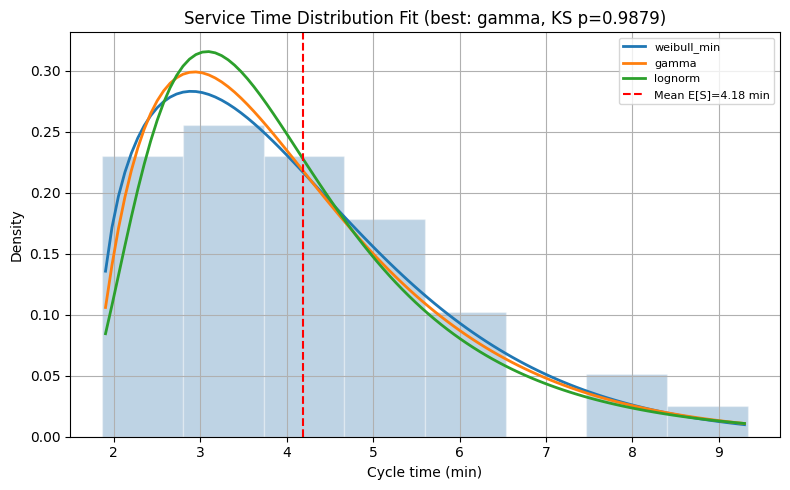

In [7]:
out_dir = "../outputs" if os.path.isdir("../outputs") else "outputs"
os.makedirs(out_dir, exist_ok=True)

L = {"xlabel": "사이클 타임 (분)" if USE_KOREAN else "Cycle time (min)",
     "ylabel": "밀도" if USE_KOREAN else "Density",
     "mean":   f"평균 E[S]={mean:.2f}분" if USE_KOREAN else f"Mean E[S]={mean:.2f} min"}

fig, ax = plt.subplots(figsize=(8,5))
try: f.plot_pdf(Nbest=3, lw=2)
except Exception: pass
ax.hist(x, bins=8, density=True, alpha=0.35, color="steelblue", edgecolor="white")
ax.axvline(mean, color="red", ls="--", lw=1.5, label=L["mean"])
ax.set_title(f"Service Time Distribution Fit (best: {best_fit}, KS p={best_p})")
ax.set_xlabel(L["xlabel"]); ax.set_ylabel(L["ylabel"]); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(out_dir,"service_time_distribution_fit.png"), dpi=130); plt.show()

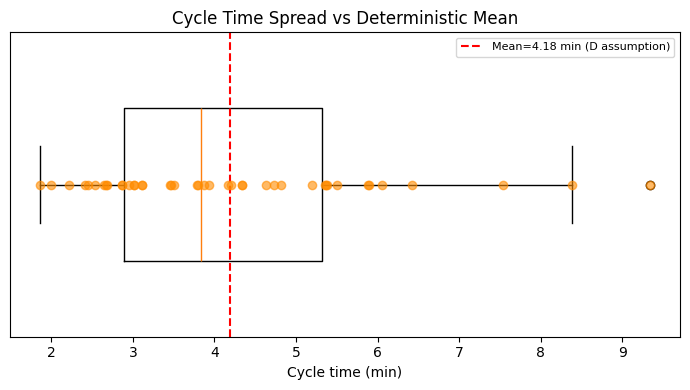

In [8]:
fig, ax = plt.subplots(figsize=(7,4))
ax.boxplot(x, vert=False, widths=0.5)
ax.scatter(x, np.ones_like(x), alpha=0.6, color="darkorange", zorder=3)
ax.axvline(mean, color="red", ls="--", lw=1.5,
           label=(f"평균={mean:.2f}분 (D 가정)" if USE_KOREAN else f"Mean={mean:.2f} min (D assumption)"))
ax.set_title("Cycle Time Spread vs Deterministic Mean")
ax.set_xlabel(L["xlabel"]); ax.set_yticks([]); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(out_dir,"cycle_time_spread.png"), dpi=130); plt.show()

**판정 결론**

> 사이클 타임이 1.87~9.33분으로 넓게 퍼져 있어 결정론적(D)이 아니다 ($C_s^2$=0.166 ≠ 0).
> 감마분포가 가장 잘 맞으므로(KS p≈0.99) 서비스 분포는 **일반분포(G)** 로 보고
> 모델은 **M/G/s/K (batch)** 계열을 사용하는 것이 타당하다.
> (M/D는 변동을 0으로 가정해 대기시간 $W_q$ 를 구조적으로 과소추정)

## 7. 최종 파라미터 정리 및 저장
큐잉 모델 균형방정식에 투입할 상숫값을 `outputs/service_time_params.json` 으로 저장.

In [9]:
mu = 1.0/mean
service_params = {
    "N_cycles": int(len(x)),
    "lambda_per_min": round(lam,4),
    "lambda_per_hour": round(lam*60,2),
    "lambda_per_session": lam_each,
    "E_S_min": round(mean,4),
    "std_min": round(std,4),
    "CV": round(cv,4),
    "CV2": round(cv2,4),
    "service_dist_verdict": verdict,
    "mu_per_min_per_car": round(mu,4),
    "best_fit_distribution": best_fit,
    "best_fit_p_value": float(best_p),
    "K_capacity": K,
    "K_mean_raw": round(float(K_mean),2),
    "K_per_session": K_each,
    "batch_size_B": BATCH_SIZE_B,
    "servers_s": SERVERS_S,
    "system_capacity_per_min": round(SERVERS_S*BATCH_SIZE_B*mu,4),
    "rho": round(lam/(SERVERS_S*BATCH_SIZE_B*mu),4),
    "ks_table": ks_df.to_dict(orient="records"),
}
print("="*55); print("최종 파라미터"); print("="*55)
for k in ["lambda_per_min","E_S_min","mu_per_min_per_car","K_capacity","CV2",
          "best_fit_distribution","service_dist_verdict","rho"]:
    print(f"  {k:22s} = {service_params[k]}")

with open(os.path.join(out_dir,"service_time_params.json"),"w",encoding="utf-8") as fp:
    json.dump(service_params, fp, ensure_ascii=False, indent=2)
print("\n✓ outputs/service_time_params.json 저장 완료")

최종 파라미터
  lambda_per_min         = 4.3556
  E_S_min                = 4.1845
  mu_per_min_per_car     = 0.239
  K_capacity             = 14
  CV2                    = 0.1662
  best_fit_distribution  = gamma
  service_dist_verdict   = 변동이 약한 G — D 가정은 변동 과소추정, M/G 권장
  rho                    = 0.3574

✓ outputs/service_time_params.json 저장 완료


## 8. 결론 (Conclusion)

### 도출된 핵심 파라미터
| 파라미터 | 값 | 의미 | 후속 사용 |
|---|---|---|---|
| **`λ`** | **4.356 명/분** (261.3/h) | 피크 1층 상행 도착률 (세션 통합) | 균형방정식 도착률 |
| **`μ`** | **0.239 cycles/분** | 호기 1대 1사이클 처리율 $\mu=1/E[S]$ | 균형방정식 서비스율 |
| **`E[S]`** | **4.184 분** | 평균 왕복 사이클 시간 | μ 산정 |
| **`K`** | **14** | 1층 대기 공간 상한 (세션 최대 10·12·21 평균) | 균형방정식 상태공간 상한 |
| 서비스 분포 | **G (gamma)** | $C_s^2$=0.166, KS p≈0.99 | M/G/s/K 모델 채택 근거 |
| `ρ` | **0.357** | 시스템 이용률 $\lambda/(sB\mu)$ | 혼잡도 진단 |

### 방법론적 의의
1. **D vs G 정량 판정**: 단순 가정이 아닌 $C_s^2$ + KS 검정으로 서비스 분포를 확정 → M/D 대신 **M/G** 채택 근거 확보.
2. **세션 통합**: 3개 피크 세션을 독립 관측치로 통합해 N=42 확보, 분포 검정 표본 충분.
3. **재현성**: raw → processed → outputs 파이프라인을 `src/service_time_analysis.py` 로도 동일하게 재현 가능.

### 한계 및 보완 방향
1. **표본 한계**: N=42 로 KS 검정이 expon 을 기각하지 못함. 다만 $C_s^2 \ll 1$ 과 SSE 비교로 G(gamma) 가 더 타당.
2. **batch 단순화**: 피크에 항상 Full-batch(B=17) 가정. 실제 평균 탑승 인원으로 보정 시 μ·ρ 재계산 필요.
3. **상층 정차 변동**: 사이클 변동의 상당분이 목적층 분포에서 기인 → 일반분포(G) 채택이 현실적임을 뒷받침.

### 남은 작업 — 큐잉 모델 풀이
```python
import json
with open("outputs/service_time_params.json") as f:
    p = json.load(f)
lam = p["lambda_per_min"]        # 4.3556  도착률
mu  = p["mu_per_min_per_car"]    # 0.239   서비스율 (호기 1대)
K   = p["K_capacity"]            # 14      대기 공간 상한
B   = p["batch_size_B"]          # 17      정원
# → M/G/s/K(batch) 균형방정식에 투입, s=3 vs s=4 비교
```
